In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.autograd import grad
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import ScalarFormatter, MaxNLocator
import time

In [2]:
def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    np.random.seed(seed)

setup_seed(123456)

In [3]:
output_dir = "Hyperelastic_NH_0.1MPa_修改稿_边界无加密"
os.makedirs(output_dir, exist_ok=True)

In [4]:
# 物理参数
delta = 0
miu0 = 0.1802e6  # Pa
miuA = 0.1802e6  # Pa
miuB = 0.3166e6  # Pa
A = 1.0          # m (内半径)
B = 2.0          # m (外半径)
Pa = -0.1e6     # Pa (内压)
Pb = 0e6         # Pa (外压)
epochs_number = 30000
eps = 1e-8

# 归一化
L_norm = B
miu_norm = miu0
P_norm_dimless = Pa / miu0 # 无量纲压力

A_norm = A / L_norm
B_norm = B / L_norm
miuA_norm = miuA / miu_norm
miuB_norm = miuB / miu_norm

In [5]:
class miu_distribution(nn.Module):

    def __init__(self):
        super(miu_distribution, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 10),
            nn.Tanh(),

            nn.Linear(10, 1),
            nn.Sigmoid()
        )

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight, gain=1.0)
                nn.init.zeros_(layer.bias)

    def forward(self, R_norm):
        
        phi = (R_norm - A_norm) / (B_norm - A_norm)

        nn_out = self.net(phi)

        linear_base = miuA_norm + (miuB_norm - miuA_norm) * phi
        
        miu_final = linear_base + phi * (1.0 - phi) * nn_out


        return miu_final


In [6]:
class Net_r(nn.Module):
    def __init__(self):
        super(Net_r, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1,20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 2) 
            
        )
        
        # Xavier初始化
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight, gain=1.0)
                nn.init.zeros_(layer.bias)

    def forward(self, R_norm):

        output = self.net(R_norm)
 
        raw_r = output[:, 0:1]
        Pr_pred = output[:, 1:2] 
        r_pred =abs(raw_r)

        return torch.cat([r_pred, Pr_pred], dim=1)

In [7]:
def compute_loss(Net_model, miu_model, R_train, epoch, total_epochs):
    
    R_train.requires_grad_(True)
    
    out = Net_model(R_train)
    r = out[:, 0:1]
    Pr = out[:, 1:2]
    
    
    ###剪切模量分布
    miu_r = miu_model(R_train)

    dr_R = grad(r, R_train, torch.ones_like(r), create_graph=True)[0]

    # NH 模型 
    I1 = (r/R_train)**(-2*delta-2) + (r/R_train)**2 + (r/R_train)**(2*delta)
    I2 = (r/R_train)**(-2*delta)*(r/R_train)**(-2) + (r/R_train)**(2*delta+2)
    
    W1 = miu_r / 2
    W2 = 0
    
    ####应力计算
    sigma_r = -Pr + 2*W1*dr_R**2 + 2*W2*((r/R_train)**2*dr_R**2 + (r/R_train)**(2*delta)*dr_R**2)
    sigma_theta = -Pr + 2*W1*(r/R_train)**2 + 2*W2*(dr_R**2*(r/R_train)**2 + (r/R_train)**(2*delta+2))
    sigma_z = -Pr + 2*W1*(r/R_train)**(2*delta) + 2*W2*(dr_R**2*(r/R_train)**(2*delta) + (r/R_train)**(2*delta+2))

     ###不可压缩条件
    J = dr_R * (r/R_train)**(delta + 1)
    
    ###平衡方程
    dsigma_r_R = grad(sigma_r, R_train, torch.ones_like(sigma_r), create_graph=True)[0]
    dsigma_r_r = dsigma_r_R / (dr_R+eps)

    balance_eq =  dsigma_r_r+ (delta + 1) * (sigma_r - sigma_theta) / (r+eps)

        
    
    # 边界值 
    R_inner = torch.tensor([[A_norm]], dtype=torch.float32,requires_grad=True)
    R_outer = torch.tensor([[B_norm]], dtype=torch.float32, requires_grad=True)
    
    miu_inner = miu_model(R_inner)
    miu_outer=miu_model(R_outer)
    
    out1 = Net_model(R_inner)
    r_inner = out1[:, 0:1]
    Pr_inner = out1[:, 1:2]
    
    dr_R_inner = grad(r_inner, R_inner, torch.ones_like(r_inner), create_graph=True)[0]
    
    W1_inner = miu_inner / 2
    W2_inner = 0 
    
    sigma_r_inner = -Pr_inner + 2*W1_inner*dr_R_inner**2 + 2*W2_inner*((r_inner/R_inner)**2*dr_R_inner**2 + (r_inner/R_inner)**(2*delta)*dr_R_inner**2)
    
    ####外边界
    out2 = Net_model(R_outer)
    r_outer= out2[:, 0:1]
    Pr_outer = out2[:, 1:2]
    dr_R_outer = grad(r_outer, R_outer, torch.ones_like(r_outer), create_graph=True)[0]
    W1_outer = miu_outer / 2
    W2_outer = 0 
    
    sigma_r_outer = -Pr_outer + 2*W1_outer*dr_R_outer**2 + 2*W2_outer*((r_outer/R_outer)**2*dr_R_outer**2 + (r_outer/R_outer)**(2*delta)*dr_R_outer**2)
    

    #######von_mises计算

    von_mises=torch.sqrt(sigma_r**2 + sigma_theta**2 + sigma_z**2 - sigma_r*sigma_theta - sigma_theta*sigma_z - sigma_z*sigma_r)
    
    # --- 损失函数 ---
    
    ####权重
    w_balance =10
    w_J = 10      # 不可压缩条件权重
    w_bc = 1000
    w_miu_bc = 1  #  剪切模量边界条件权重
    w_mono = 1    # 单调性约束权重
    w_vm = 0.1   # von Mises应力权重
    
#####损失函数计算
    
    # 平衡方程 Loss
    loss_balance = w_balance* torch.mean(balance_eq**2)
    
    # 几何约束 Loss
    loss_J = w_J * torch.mean((J - 1)**2)
    
    # 应力边界 Loss 

    loss_bc_inner = w_bc * torch.mean((sigma_r_inner - P_norm_dimless)**2)
    loss_bc_outer = w_bc * torch.mean((sigma_r_outer)**2)
    loss_bc_stress = loss_bc_inner + loss_bc_outer
                            
    #单调性损失
    dmiu_dr = grad(miu_r, R_train, torch.ones_like(miu_r), create_graph=True)[0]
    loss_mono = w_mono * torch.mean(torch.relu(-dmiu_dr)**2)
    
    #von Mises损失

    loss_vm = w_vm * torch.max(von_mises)
                                    
   ####总损失                     

    total_loss = loss_balance + loss_J + loss_bc_stress + loss_mono + loss_vm 
     
    
  # 材料边界 Loss 
    
    miu_bc_loss_inner = w_miu_bc  * torch.mean((miu_model(torch.tensor([A_norm], dtype=torch.float32).view(-1, 1)) - miuA_norm)**2)
    miu_bc_loss_outer = w_miu_bc * torch.mean((miu_model(torch.tensor([B_norm], dtype=torch.float32).view(-1, 1)) - miuB_norm)**2)
    loss_bc_miu = miu_bc_loss_inner + miu_bc_loss_outer

        # 监控指标
    loss_dict = {
        'total': total_loss.item(),
        'loss_balance': loss_balance.item(),
        'loss_J': loss_J.item(),
        'loss_bc_stress': loss_bc_stress.item(),
        'loss_bc_miu': loss_bc_miu.item(),
        'loss_bc_inner': loss_bc_inner.item(),
        'loss_bc_outer': loss_bc_outer.item(),
        'loss_miu_bc_inner': miu_bc_loss_inner.item(),
        'loss_miu_bc_outer': miu_bc_loss_outer.item(),
        'loss_vm': loss_vm.item(),
        'loss_mono': loss_mono.item(),
        'sigma_r_inner': sigma_r_inner.item(),
        'sigma_r_outer': sigma_r_outer.item(),
        'miu_inner': miu_inner.item(),
        'miu_outer': miu_outer.item()
    }


    return total_loss, loss_dict, miu_r, sigma_r, sigma_theta, von_mises


In [8]:
# ==================== 主程序 绘图 ====================
if __name__ == "__main__":
    
    start_time = time.time()
    
    Net_model= Net_r()
    miu_model= miu_distribution()
    
    print(f"Total parameters: {sum(p.numel() for p in Net_model.parameters()) + sum(p.numel() for p in miu_model.parameters())}")

    optimizer = torch.optim.Adam([
        {'params': Net_model.parameters(), 'lr': 1e-4},
        {'params': miu_model.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-6)
    

#####学习率调度
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=1500, T_mult=2, eta_min=1e-6)
    

    # 采样点  
    n_total = 2001


    # 在整个径向区域 [A_norm, B_norm] 上均匀取点
    R_train = torch.linspace(A_norm, B_norm, n_total).view(-1, 1)
    

    print(f"Training points: {R_train.shape[0]}")
    print(f"miuA_norm (target): {miuA_norm:.4f}")
    print(f"miuB_norm (target): {miuB_norm:.4f}")


    # 训练循环
    loss_history = []
    vm_history = []
    bc_history = []
    miu_bc_history = []
    best_loss = float('inf')
    best_models = {}

    start_time = time.time()
    

    for epoch in range(epochs_number):
        optimizer.zero_grad()
 
        
        loss, loss_dict,miu_r, sigma_r, sigma_theta, von_mises  = compute_loss(Net_model, miu_model, R_train, epoch, epochs_number)
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
            
        # 记录损失  
        loss_history.append(loss_dict['total'])
        vm_history.append(torch.max(von_mises).item())
        bc_history.append(loss_dict['loss_bc_stress'])
        miu_bc_history.append(loss_dict['loss_bc_miu'])
        
        # 保存最佳模型
        if loss_dict['total'] < best_loss:
            best_loss = loss_dict['total']
            best_models = {
                'Net_model': Net_model.state_dict(),
                'miu_model': miu_model.state_dict(),
                'epoch': epoch
            }
            

            
            
        if epoch % 100 == 0:
            print(f"\nEpoch {epoch}:")
            print(f"  Total Loss: {loss_dict['total']:.2e}")
            print(f"  Balance: {loss_dict['loss_balance']:.2e}")
            print(f"  Bc_stress: {loss_dict['loss_bc_stress']:.2e}")
            print(f"  Bc_miu: {loss_dict['loss_bc_miu']:.2e}")
            print(f"  loss_mono: {loss_dict['loss_mono']:.2e}")
            print(f"  loss_vm: {loss_dict['loss_vm']:.2e}")
    
      # 加载最佳模型
    Net_model.load_state_dict(best_models['Net_model'])
    miu_model.load_state_dict(best_models['miu_model'])
    print(f"Loaded best model from epoch {best_models['epoch']} with loss {best_loss:.4e}")


    total_time = time.time() - start_time
    print(f"\nTotal time: {total_time:.1f} seconds")

    print("\nEvaluating final model...")
   

    # 评估数据生成
    R_test = torch.linspace(A_norm, B_norm, 2001).view(-1, 1).requires_grad_(True)

    with torch.no_grad():
        out_test = Net_model(R_test)
        r_test = out_test[:, 0:1]
        Pr_test = out_test[:, 1:2]
        miu_test = miu_model(R_test)
        
        r_phys = r_test.numpy() * L_norm
        R_phys = R_test.numpy() * L_norm
        miu_phys = miu_test.numpy() * miu0
        lamdatheta_phys = r_phys / R_phys

    # 计算梯度
    R_test.requires_grad_(True)
    out_test = Net_model(R_test)
    r_test = out_test[:, 0:1]
    Pr_test = out_test[:, 1:2]

    dr_dR_test = grad(r_test, R_test, torch.ones_like(r_test), create_graph=False)[0]

    with torch.no_grad():
        W1_test = miu_test / 2
        W2_test = 0
        W1_test_np=W1_test.numpy()
        W2_test_np=W2_test
        Pr_np = Pr_test.numpy()
        dr_dR_np = dr_dR_test.numpy()
        r_np = r_test.numpy()
        R_np = R_test.numpy()

        # 应力公式 (Pa)
        sigma_r_np = -Pr_np + 2*W1_test_np*dr_dR_np**2 + 2*W2_test_np*((r_np/R_np)**2*dr_dR_np**2 + (r_np/R_np)**(2*delta)*dr_dR_np**2)

        sigma_theta_np = -Pr_np + 2*W1_test_np*(r_np/R_np)**2 + 2*W2_test_np*(dr_dR_np**2*(r_np/R_np)**2 + (r_np/R_np)**(2*delta+2))
        
        sigma_z_np =-Pr_np + 2*W1_test_np*(r_np/R_np)**(2*delta) + 2*W2_test_np*(dr_dR_np**2*(r_np/R_np)**(2*delta) + (r_np/R_np)**(2*delta+2))
        
        ####转换为物理量
        sigma_r_phys=sigma_r_np * miu_norm
        sigma_theta_phys=sigma_theta_np* miu_norm
        sigma_z_phys=sigma_z_np* miu_norm
        
        ####von_mises

        von_mises = np.sqrt(sigma_r_phys**2 + sigma_theta_phys**2 + sigma_z_phys**2 - \
                sigma_r_phys*sigma_theta_phys - sigma_theta_phys*sigma_z_phys - sigma_z_phys*sigma_r_phys)/1e6 
        
        max_vm = np.max(von_mises)


    # 保存到Excel
    data_dict = {
        'Radius (m)': R_phys.flatten(),
        'Shear Modulus (GPa)': (miu_phys / 1e6).flatten(),
        'Deformation r (m)': r_phys.flatten(),
        'Radial Stress (MPa)': (sigma_r_phys / 1e6).flatten(),
        'Circumferential Stress (MPa)': (sigma_theta_phys / 1e6).flatten(),
        'Axial Stress (MPa)': (sigma_z_phys / 1e6).flatten(),
        'Deformation Ratio (m)': lamdatheta_phys.flatten(),
        'von Mises Stress (MPa)': von_mises.flatten()
    }

    df = pd.DataFrame(data_dict)
    excel_path = os.path.join(output_dir, 'optimized_results.xlsx')
    df.to_excel(excel_path, index=False)
    print(f"\nResults saved to {excel_path}")
    

# ==================== 绘图====================
    theta = np.linspace(0, 2 * np.pi, 100)
    plt.rcrams['font.family'] = 'Times New Roman'
    plt.rcParams['mathtext.fontset'] = 'stix'


    def create_polar_plots(r, data, title, filename, label):
        R, Theta = np.meshgrid(r.flatten(), theta)
        X = R * np.cos(Theta)
        Y = R * np.sin(Theta)
        Data_2D = np.tile(data.flatten(), (len(theta), 1))

        fig = plt.figure(figsize=(8, 8))
        ax = plt.gca()

        contour = ax.contourf(X, Y, Data_2D, levels=50, cmap='jet')

        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        ax.set_xticks(np.arange(-2, 2.1, 0.5))
        ax.set_yticks(np.arange(-2, 2.1, 0.5))

        ax.set_xlabel('X (m)', fontname='Times New Roman', fontsize=20)
        ax.set_ylabel('Y (m)', fontname='Times New Roman', fontsize=20)
        ax.set_title(title, fontname='Times New Roman', fontsize=20)

        for tick in ax.get_xticklabels():
            tick.set_fontname('Times New Roman')
            tick.set_fontsize(20)
        for tick in ax.get_yticklabels():
            tick.set_fontname('Times New Roman')
            tick.set_fontsize(20)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.15)
        cbar = plt.colorbar(contour, cax=cax)
        cbar.set_label(label, fontname='Times New Roman', fontsize=20)

        if "Displacement" in title:
            formatter = ScalarFormatter(useMathText=True)
            formatter.set_powerlimits((-3, 3))
            cbar.formatter = formatter
            cbar.update_ticks()
            cbar.ax.yaxis.get_offset_text().set_fontname('Times New Roman')
            cbar.ax.yaxis.get_offset_text().set_fontsize(20)

        cbar.locator = MaxNLocator(5)
        cbar.update_ticks()
        for tick in cbar.ax.get_yticklabels():
            tick.set_fontname('Times New Roman')
            tick.set_fontsize(20)

        ax.set_aspect('equal')
        plt.savefig(os.path.join(output_dir, filename), dpi=300, format='tiff', bbox_inches='tight')
        plt.close()


    # 创建所有图表
    create_polar_plots(R_phys, lamdatheta_phys, 'Optimized: Deformation Ratio (m)', 'optimized_Deformation_Ratio.tiff',
                       'Deformation Ratio (m)')
    create_polar_plots(R_phys, miu_phys / 1e6, 'Optimized Shear Modulus Distribution (MPa)',
                       'optimized_miu_distribution.tiff', 'Shear Modulus (MPa)')
    create_polar_plots(R_phys, sigma_r_phys / 1e6, 'Optimized: Radial Stress (MPa)', 'optimized_radial_stress.tiff',
                       'Radial Stress (MPa)')
    create_polar_plots(R_phys, sigma_theta_phys / 1e6, 'Optimized: Circumferential Stress (MPa)',
                       'optimized_circumferential_stress.tiff', 'Circumferential Stress (MPa)')
    create_polar_plots(R_phys, sigma_z_phys / 1e6, 'Optimized: Axial Stress (MPa)',
                       'optimized_Axial_stress.tiff', 'Axial Stress (MPa)')
    create_polar_plots(R_phys, von_mises, 'Optimized: von Mises Stress (MPa)', 'optimized_von_mises_stress.tiff',
                       'von Mises Stress (MPa)')

    # 损失曲线
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].semilogy(loss_history, linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontname='Times New Roman', fontsize=14)
    axes[0, 0].set_ylabel('Loss', fontname='Times New Roman', fontsize=14)
    axes[0, 0].set_title('Training Loss History', fontname='Times New Roman', fontsize=14)
    axes[0, 0].grid(False)
    axes[0, 0].tick_params(labelsize=12)

    axes[0, 1].plot(vm_history, linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontname='Times New Roman', fontsize=14)
    axes[0, 1].set_ylabel('von Mises Stress', fontname='Times New Roman', fontsize=14)
    axes[0, 1].set_title('Maximum von Mises Stress History', fontname='Times New Roman', fontsize=14)
    axes[0, 1].grid(False)
    axes[0, 1].tick_params(labelsize=12)

    axes[1, 0].plot(bc_history, linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontname='Times New Roman', fontsize=14)
    axes[1, 0].set_ylabel('Stress BC Error (%)', fontname='Times New Roman', fontsize=14)
    axes[1, 0].set_title('Stress Boundary Condition Error History', fontname='Times New Roman', fontsize=14)
    axes[1, 0].grid(False)
    axes[1, 0].tick_params(labelsize=12)

    axes[1, 1].plot(miu_bc_history, linewidth=2)
    axes[1, 1].set_xlabel('Epoch', fontname='Times New Roman', fontsize=14)
    axes[1, 1].set_ylabel('miu BC Error (%)', fontname='Times New Roman', fontsize=14)
    axes[1, 1].set_title('Shear Modulus BC Error History', fontname='Times New Roman', fontsize=14)
    axes[1, 1].grid(False)
    axes[1, 1].tick_params(labelsize=12)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'training_history.tiff'), dpi=300, format='tiff', bbox_inches='tight')
    plt.close()

    # 剪切模量分布图
    plt.figure(figsize=(10, 8))
    plt.plot(R_phys, miu_phys / 1e6, label='Optimized miu(r)', linewidth=3, color='blue')

    # 标记边界点
    plt.scatter([A, B], [miuA / 1e6, miuB / 1e6], color='red', s=150,
                marker='o', edgecolors='black', linewidth=2, zorder=5,
                label=f'')

 
    plt.xlabel(r'$\mathit{r/b}$ ', fontsize=26)
    plt.ylabel('Shear Modulus (MPa)', fontsize=26)
    plt.title('Optimized Shear Modulus Distribution\n(Strict Boundary Conditions Enforced)', fontsize=22)
    plt.legend(fontsize=14, loc='best')
    plt.grid(False)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.savefig(os.path.join(output_dir, 'optimized_miu_distribution_curve.tiff'), dpi=300, format='tiff',
                bbox_inches='tight')
    plt.close()

    # 应力分布对比图
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    axes[0, 0].plot(R_phys, sigma_r_phys / 1e6, linewidth=2)
    axes[0, 0].set_xlabel(r'$\mathit{R}$ (m)', fontsize=18)
    axes[0, 0].set_ylabel('Radial Stress (MPa)', fontsize=18)
    axes[0, 0].set_title('Radial Stress Distribution', fontsize=18)
    axes[0, 0].grid(False)
    axes[0, 0].tick_params(labelsize=14)

    axes[0, 1].plot(R_phys, sigma_theta_phys / 1e6, linewidth=2)
    axes[0, 1].set_xlabel(r'$\mathit{R}$ (m)', fontsize=18)
    axes[0, 1].set_ylabel('Circumferential Stress (MPa)', fontsize=18)
    axes[0, 1].set_title('Circumferential Stress Distribution', fontsize=18)
    axes[0, 1].grid(False)
    axes[0, 1].tick_params(labelsize=14)
    
#     axes[0, 1].plot(R_phys, sigma_z_phys / 1e6, linewidth=2)
#     axes[0, 1].set_xlabel(r'$\mathit{R}$ (m)', fontsize=18)
#     axes[0, 1].set_ylabel('Axial Stress (MPa)', fontsize=18)
#     axes[0, 1].set_title('Axial Stress Distribution', fontsize=18)
#     axes[0, 1].grid(False)
#     axes[0, 1].tick_params(labelsize=14)

    axes[1, 0].plot(R_phys, von_mises , linewidth=2)
    axes[1, 0].axhline(y=max_vm, color='r', linestyle='--', alpha=0.7, label=f'Max: {max_vm:.1f} MPa')
    axes[1, 0].set_xlabel(r'$\mathit{R}$ (m)', fontsize=18)
    axes[1, 0].set_ylabel('von Mises Stress (MPa)', fontsize=18)
    axes[1, 0].set_title('von Mises Stress Distribution', fontsize=18)
    axes[1, 0].legend(fontsize=14)
    axes[1, 0].grid(False)
    axes[1, 0].tick_params(labelsize=14)

    axes[1, 1].plot(R_phys, lamdatheta_phys, linewidth=2)  # 转换为mm
    axes[1, 1].set_xlabel(r'$\mathit{R}$ (m)', fontsize=18)
    axes[1, 1].set_ylabel('Deformation Ratio (m)', fontsize=18)
    axes[1, 1].set_title('Deformation Ratio Distribution', fontsize=18)
    axes[1, 1].grid(False)
    axes[1, 1].tick_params(labelsize=14)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'stress_displacement_summary.tiff'), dpi=300, format='tiff',
                bbox_inches='tight')
    plt.close()

    print(f"\n{'=' * 60}")
    print(f"优化完成!")
    print(f"总时间: {total_time:.1f} 秒")
    print(f"最终损失: {loss_history[-1]:.2e}")
    print(f"最大von Mises应力: {max_vm:.2f} MPa")
    print(f"所有结果已保存到 {output_dir} 文件夹")
    print(f"{'=' * 60}")

Total parameters: 1483
Training points: 2001
miuA_norm (target): 1.0000
miuB_norm (target): 1.7569

Epoch 0:
  Total Loss: 3.00e+02
  Balance: 4.45e+01
  Bc_stress: 2.46e+02
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.75e-01

Epoch 100:
  Total Loss: 1.70e+02
  Balance: 9.16e-01
  Bc_stress: 1.59e+02
  Bc_miu: 0.00e+00
  loss_mono: 2.01e-03
  loss_vm: 1.75e-01

Epoch 200:
  Total Loss: 1.34e+02
  Balance: 5.73e+00
  Bc_stress: 1.18e+02
  Bc_miu: 0.00e+00
  loss_mono: 7.77e-03
  loss_vm: 1.72e-01

Epoch 300:
  Total Loss: 9.08e+01
  Balance: 9.14e+00
  Bc_stress: 7.34e+01
  Bc_miu: 0.00e+00
  loss_mono: 8.64e-03
  loss_vm: 1.62e-01

Epoch 400:
  Total Loss: 5.22e+01
  Balance: 1.02e+01
  Bc_stress: 3.54e+01
  Bc_miu: 0.00e+00
  loss_mono: 6.76e-03
  loss_vm: 1.48e-01

Epoch 500:
  Total Loss: 2.71e+01
  Balance: 7.42e+00
  Bc_stress: 1.49e+01
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.34e-01

Epoch 600:
  Total Loss: 1.37e+01
  Balance: 4.40e+00
  Bc_stress: 6.01e+0


Epoch 5900:
  Total Loss: 2.13e-01
  Balance: 2.04e-03
  Bc_stress: 1.10e-03
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.21e-01

Epoch 6000:
  Total Loss: 2.10e-01
  Balance: 1.99e-03
  Bc_stress: 1.24e-04
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.21e-01

Epoch 6100:
  Total Loss: 2.08e-01
  Balance: 1.95e-03
  Bc_stress: 6.69e-04
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.21e-01

Epoch 6200:
  Total Loss: 2.05e-01
  Balance: 1.89e-03
  Bc_stress: 1.20e-04
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.21e-01

Epoch 6300:
  Total Loss: 2.03e-01
  Balance: 1.84e-03
  Bc_stress: 1.23e-04
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.22e-01

Epoch 6400:
  Total Loss: 2.00e-01
  Balance: 1.80e-03
  Bc_stress: 1.09e-04
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.22e-01

Epoch 6500:
  Total Loss: 1.98e-01
  Balance: 1.75e-03
  Bc_stress: 1.14e-04
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.22e-01

Epoch 6600:
  Total Loss: 


Epoch 11800:
  Total Loss: 1.57e-01
  Balance: 9.84e-04
  Bc_stress: 6.66e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.25e-01

Epoch 11900:
  Total Loss: 1.57e-01
  Balance: 9.78e-04
  Bc_stress: 6.65e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.25e-01

Epoch 12000:
  Total Loss: 1.56e-01
  Balance: 9.73e-04
  Bc_stress: 6.65e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.25e-01

Epoch 12100:
  Total Loss: 1.56e-01
  Balance: 9.67e-04
  Bc_stress: 6.62e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.25e-01

Epoch 12200:
  Total Loss: 1.56e-01
  Balance: 9.63e-04
  Bc_stress: 6.58e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.25e-01

Epoch 12300:
  Total Loss: 1.55e-01
  Balance: 9.58e-04
  Bc_stress: 6.55e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.25e-01

Epoch 12400:
  Total Loss: 1.55e-01
  Balance: 9.52e-04
  Bc_stress: 6.55e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.25e-01

Epoch 12500:
  Tota


Epoch 17700:
  Total Loss: 1.35e-01
  Balance: 6.80e-04
  Bc_stress: 6.39e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 17800:
  Total Loss: 1.35e-01
  Balance: 6.82e-04
  Bc_stress: 6.28e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 17900:
  Total Loss: 1.35e-01
  Balance: 6.76e-04
  Bc_stress: 6.44e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 18000:
  Total Loss: 1.35e-01
  Balance: 6.85e-04
  Bc_stress: 8.26e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 18100:
  Total Loss: 1.34e-01
  Balance: 6.70e-04
  Bc_stress: 7.68e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 18200:
  Total Loss: 1.34e-01
  Balance: 6.75e-04
  Bc_stress: 6.32e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 18300:
  Total Loss: 1.34e-01
  Balance: 6.69e-04
  Bc_stress: 6.90e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 18400:
  Tota


Epoch 23600:
  Total Loss: 1.32e-01
  Balance: 6.40e-04
  Bc_stress: 6.85e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 23700:
  Total Loss: 1.32e-01
  Balance: 6.42e-04
  Bc_stress: 6.84e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 23800:
  Total Loss: 1.32e-01
  Balance: 6.42e-04
  Bc_stress: 6.84e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 23900:
  Total Loss: 1.32e-01
  Balance: 6.43e-04
  Bc_stress: 6.86e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 24000:
  Total Loss: 1.32e-01
  Balance: 6.43e-04
  Bc_stress: 6.86e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 24100:
  Total Loss: 1.32e-01
  Balance: 6.44e-04
  Bc_stress: 6.84e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 24200:
  Total Loss: 1.32e-01
  Balance: 6.43e-04
  Bc_stress: 6.87e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.28e-01

Epoch 24300:
  Tota


Epoch 29500:
  Total Loss: 1.31e-01
  Balance: 7.02e-04
  Bc_stress: 7.45e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.27e-01

Epoch 29600:
  Total Loss: 1.31e-01
  Balance: 6.97e-04
  Bc_stress: 9.84e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.27e-01

Epoch 29700:
  Total Loss: 1.31e-01
  Balance: 7.03e-04
  Bc_stress: 7.63e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.27e-01

Epoch 29800:
  Total Loss: 1.31e-01
  Balance: 7.09e-04
  Bc_stress: 7.65e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.27e-01

Epoch 29900:
  Total Loss: 1.31e-01
  Balance: 7.06e-04
  Bc_stress: 7.94e-05
  Bc_miu: 0.00e+00
  loss_mono: 0.00e+00
  loss_vm: 1.27e-01
Loaded best model from epoch 29997 with loss 1.3109e-01

Total time: 591.8 seconds

Evaluating final model...

Results saved to Hyperelastic_NH_0.1MPa_修改稿_边界无加密\optimized_results.xlsx

优化完成!
总时间: 591.8 秒
最终损失: 1.31e-01
最大von Mises应力: 0.23 MPa
所有结果已保存到 Hyperelastic_NH_0.1MPa_修改稿_边界无加密 文件夹


In [9]:
print(max_vm)

0.22908862


In [10]:
print(sigma_r_phys)

[[-9.9971797e+04]
 [-9.9903672e+04]
 [-9.9835617e+04]
 ...
 [-1.0401349e+02]
 [-7.5034927e+01]
 [-4.6013405e+01]]


In [11]:
print(r_phys,lamdatheta_phys)

[[1.4092398]
 [1.4096158]
 [1.409992 ]
 ...
 [2.232227 ]
 [2.2326722]
 [2.2331176]] [[1.4092398]
 [1.4089113]
 [1.4085833]
 ...
 [1.1166718]
 [1.1166153]
 [1.1165588]]


<function matplotlib.pyplot.show(*args, **kw)>

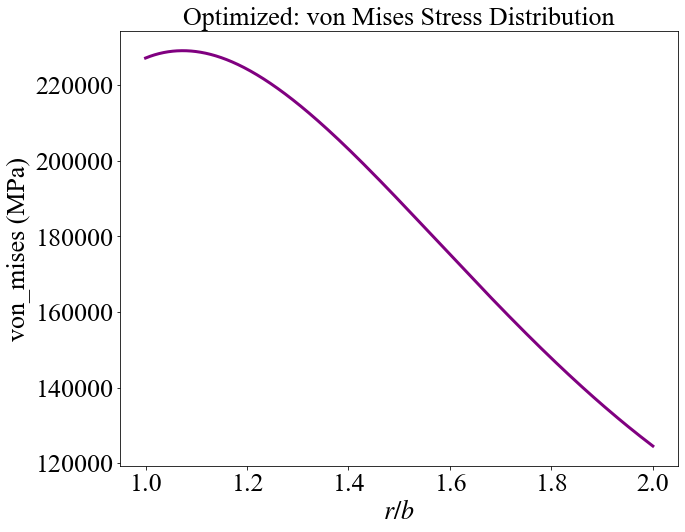

In [12]:

plt.figure(figsize=(10, 8))
plt.plot(R_phys/A, von_mises*1e6, linewidth=3, color='purple')
plt.xlabel(r'$\it{r/b}$', fontsize=26)
plt.ylabel('von_mises (MPa)', fontsize=26)
plt.title('Optimized: von Mises Stress Distribution', fontsize=26)
plt.grid(False)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26)
plt.show

<function matplotlib.pyplot.show(*args, **kw)>

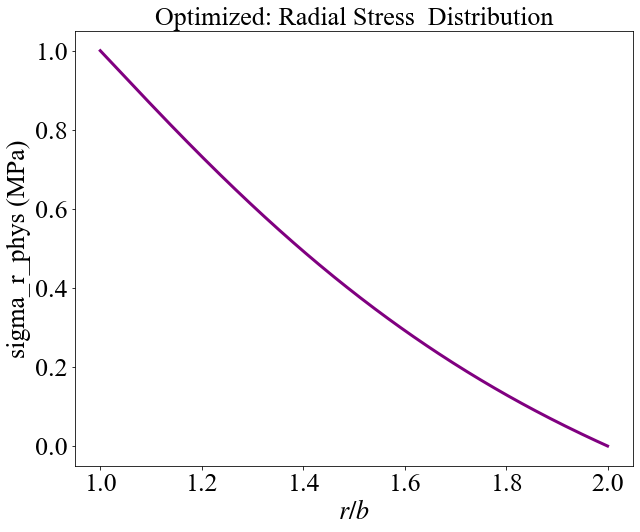

In [13]:

plt.figure(figsize=(10, 8))
plt.plot(R_phys/A, sigma_r_phys/Pa, linewidth=3, color='purple')
plt.xlabel(r'$\it{r/b}$', fontsize=26)
plt.ylabel('sigma_r_phys (MPa)', fontsize=26)
plt.title('Optimized: Radial Stress  Distribution', fontsize=26)
plt.grid(False)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26)
plt.show

<function matplotlib.pyplot.show(*args, **kw)>

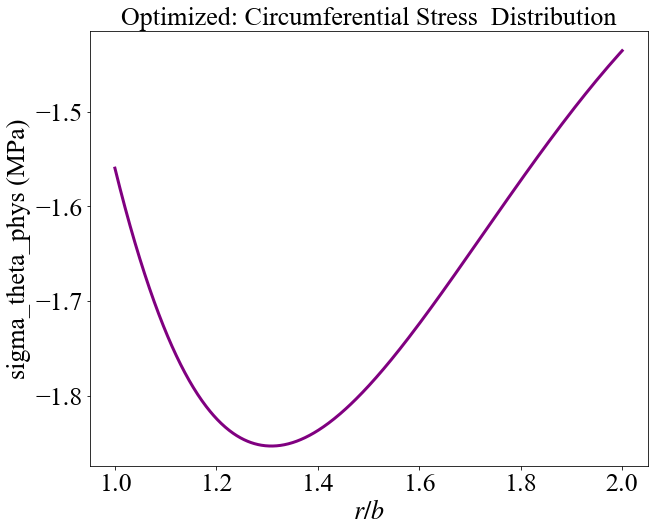

In [14]:

    plt.figure(figsize=(10, 8))
    plt.plot(R_phys/A, sigma_theta_phys/Pa, linewidth=3, color='purple')
    plt.xlabel(r'$\it{r/b}$', fontsize=26)
    plt.ylabel('sigma_theta_phys (MPa)', fontsize=26)
    plt.title('Optimized: Circumferential Stress  Distribution', fontsize=26)
    plt.grid(False)
    plt.xticks(fontsize=26)
    plt.yticks(fontsize=26)
    plt.show

<function matplotlib.pyplot.show(*args, **kw)>

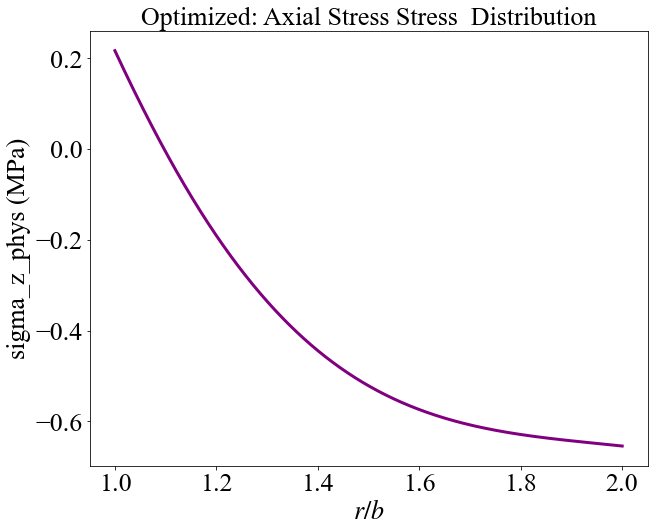

In [15]:

    plt.figure(figsize=(10, 8))
    plt.plot(R_phys/A, sigma_z_phys/Pa, linewidth=3, color='purple')
    plt.xlabel(r'$\it{r/b}$', fontsize=26)
    plt.ylabel('sigma_z_phys (MPa)', fontsize=26)
    plt.title('Optimized: Axial Stress Stress  Distribution', fontsize=26)
    plt.grid(False)
    plt.xticks(fontsize=26)
    plt.yticks(fontsize=26)
    plt.show

<function matplotlib.pyplot.show(*args, **kw)>

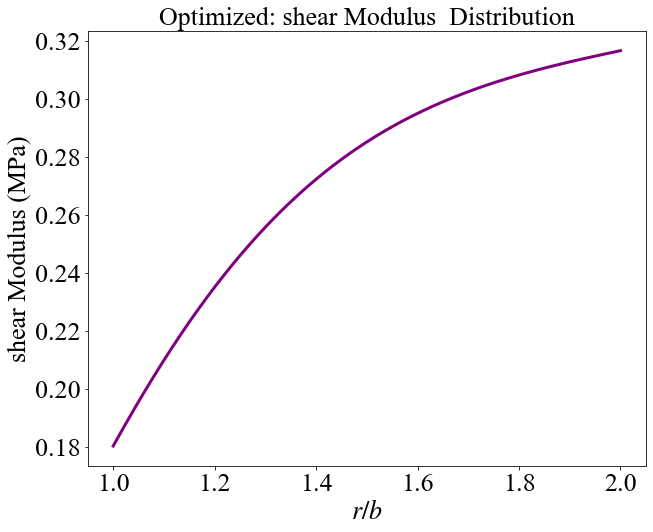

In [16]:

    plt.figure(figsize=(10, 8))
    plt.plot(R_phys/A, miu_phys / 1e6, linewidth=3, color='purple')
    plt.xlabel(r'$\it{r/b}$', fontsize=26)
    plt.ylabel('shear Modulus (MPa)', fontsize=26)
    plt.title('Optimized: shear Modulus  Distribution', fontsize=26)
    plt.grid(False)
    plt.xticks(fontsize=26)
    plt.yticks(fontsize=26)
    plt.show

In [17]:
# ==================== 额外保存所有绘图专用数据 ====================
print("\n正在保存绘图专用数据 (CSV格式)...")

# 1. 保存训练历史数据 (Loss, von Mises, 以及边界条件误差历史)
# 对应图表: training_history.tiff
history_df = pd.DataFrame({
    'Epoch': range(len(loss_history)),
    'Total_Loss': loss_history,
    'von_Mises_MPa': vm_history,
    'Stress_BC_Error_Pct': bc_history,
    'Miu_BC_Error_Pct': miu_bc_history
})
history_file = os.path.join(output_dir, 'plotdata_training_history.csv')
history_df.to_csv(history_file, index=False)

# 2. 保存一维径向分布完整数据 (用于绘制 2D 线图)
# 对应图表: optimized_miu_distribution_curve.tiff, stress_displacement_summary.tiff
spatial_data_df = pd.DataFrame({
    'R_phys_m': R_phys.flatten(),
    'R_over_B': R_phys.flatten() / B,
    'r_phys_m': r_phys.flatten(),
    'Deformation_Ratio': lamdatheta_phys.flatten(),
    'Shear_Modulus_MPa': (miu_phys / 1e6).flatten(),
    'Radial_Stress_MPa': (sigma_r_phys / 1e6).flatten(),
    'Circumferential_Stress_MPa': (sigma_theta_phys / 1e6).flatten(),
    'Axial_Stress_MPa': (sigma_z_phys / 1e6).flatten(),
    'von_Mises_MPa': von_mises.flatten()
})
spatial_file = os.path.join(output_dir, 'plotdata_spatial_distributions.csv')
spatial_data_df.to_csv(spatial_file, index=False)

# 3. 保存二维平面云图数据 (包含 X 和 Y 坐标映射，用于 Origin/Tecplot 绘制 Contour 图)
# 对应图表: 所有 create_polar_plots 生成的云图
theta_arr = np.linspace(0, 2 * np.pi, 100)
R_grid, Theta_grid = np.meshgrid(R_phys.flatten(), theta_arr)

# 极坐标到直角坐标的转换
X_grid = R_grid * np.cos(Theta_grid)
Y_grid = R_grid * np.sin(Theta_grid)

# 定义辅助函数：将1D数据沿圆周扩展匹配X和Y网格，并展平为一维列用于存入CSV
def expand_to_2d_col(data_1d):
    return np.tile(data_1d.flatten(), (len(theta_arr), 1)).flatten()

contour_data_df = pd.DataFrame({
    'X_m': X_grid.flatten(),
    'Y_m': Y_grid.flatten(),
    'R_m': R_grid.flatten(),
    'Theta_rad': Theta_grid.flatten(),
    'Shear_Modulus_MPa': expand_to_2d_col(miu_phys / 1e6),
    'Deformation_Ratio': expand_to_2d_col(lamdatheta_phys),
    'Radial_Stress_MPa': expand_to_2d_col(sigma_r_phys / Pa),
    'Circumferential_Stress_MPa': expand_to_2d_col(sigma_theta_phys / Pa),
    'Axial_Stress_MPa': expand_to_2d_col(sigma_z_phys / Pa),
    'von_Mises_MPa': expand_to_2d_col(von_mises)
})
contour_file = os.path.join(output_dir, 'plotdata_2D_contours.csv')
contour_data_df.to_csv(contour_file, index=False)

print(f"绘图数据已成功保存，包含以下文件：")
print(f" - {os.path.basename(history_file)} (训练损失与边界误差历史)")
print(f" - {os.path.basename(spatial_file)} (一维径向分布线图数据)")
print(f" - {os.path.basename(contour_file)} (二维云图对应的 X, Y 网格数据，共 {len(contour_data_df)} 行)")
print("=" * 60)


正在保存绘图专用数据 (CSV格式)...
绘图数据已成功保存，包含以下文件：
 - plotdata_training_history.csv (训练损失与边界误差历史)
 - plotdata_spatial_distributions.csv (一维径向分布线图数据)
 - plotdata_2D_contours.csv (二维云图对应的 X, Y 网格数据，共 200100 行)


In [18]:
data = pd.read_csv('COMSOL_NH_miu_double_zhu_youhua.csv')
R_bar_COMSOL = data.iloc[:, 0:1].to_numpy()
sigmar_COMSOL = data.iloc[:, 1:2].to_numpy()
sigmatheta_COMSOL = data.iloc[:, 2:3].to_numpy()
sigmaz_COMSOL = data.iloc[:, 3:4].to_numpy()
lamdatheta_COMSOL = data.iloc[:, 4:5].to_numpy()
von_mises_COMSOL = data.iloc[:, 5:6].to_numpy()
miu_COMSOL = data.iloc[:, 6:7].to_numpy()

In [19]:
# 获取COMSOL数据
COMSOL_R = R_bar_COMSOL.flatten()
COMSOL_sigma_r = sigmar_COMSOL[:,0:1]  
COMSOL_sigma_theta = sigmatheta_COMSOL[:,0:1]  
COMSOL_sigma_z = sigmaz_COMSOL[:, 0:1]  
COMSOL_lamdatheta = lamdatheta_COMSOL[:,0:1] 
COMSOL_von_mises = von_mises_COMSOL[:,0:1]*Pa/1e6
COMSOL_miu = miu_COMSOL[:,0:1] 

In [20]:
print(max(COMSOL_von_mises))

[0.24290695]


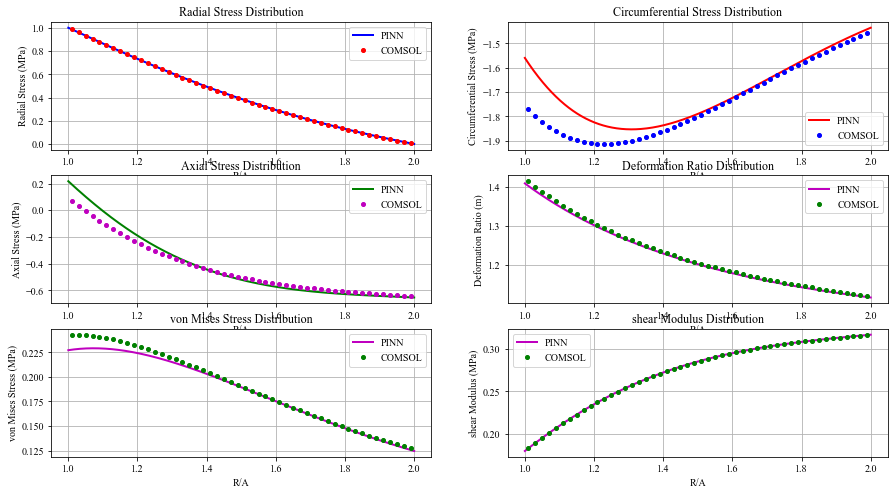

In [21]:
plt.figure(figsize=(15, 8))


plt.subplot(3, 2, 1)
plt.plot(R_phys/A, sigma_r_phys/Pa, 'b-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_sigma_r, 'ro', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Radial Stress (MPa)')
plt.title('Radial Stress Distribution')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(R_phys/A, sigma_theta_phys/Pa, 'r-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_sigma_theta, 'bo', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Circumferential Stress (MPa)')
plt.title('Circumferential Stress Distribution')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 3)
plt.plot(R_phys/A, sigma_z_phys/Pa, 'g-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_sigma_z, 'mo', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Axial Stress (MPa)')
plt.title('Axial Stress Distribution')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(R_phys/A, lamdatheta_phys, 'm-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_lamdatheta, 'go', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Deformation Ratio (m)')
plt.title('Deformation Ratio Distribution')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 5)
plt.plot(R_phys/A, von_mises, 'm-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_von_mises, 'go', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('von Mises Stress (MPa)')
plt.title('von Mises Stress Distribution')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 6)
plt.plot(R_phys/A, miu_phys / 1e6, 'm-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_miu/ 1e6, 'go', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('shear Modulus (MPa)')
plt.title('shear Modulus Distribution')
plt.legend()
plt.grid(True)


In [22]:
# 创建极坐标网格
sigma_r_phys/Pa
miu_phys
theta = np.linspace(0, 2 * np.pi, 100)
R = R_phys.flatten()  # 展平半径数组
Theta, R_grid = np.meshgrid(theta, R)
X_PINN = R_grid * np.cos(Theta)
Y_PINN = R_grid * np.sin(Theta)

# 将一维预测数据扩展为二维网格数据
sigma_r_2d = np.tile(sigma_r_phys.flatten()/ Pa, (len(theta), 1)).T
sigma_theta_2d = np.tile(sigma_theta_phys.flatten()/ Pa, (len(theta), 1)).T
sigma_z_2d = np.tile(sigma_z_phys.flatten() / Pa, (len(theta), 1)).T
von_mises_2d = np.tile(von_mises.flatten() , (len(theta), 1)).T
lamdatheta_2d = np.tile(lamdatheta_phys.flatten(), (len(theta), 1)).T

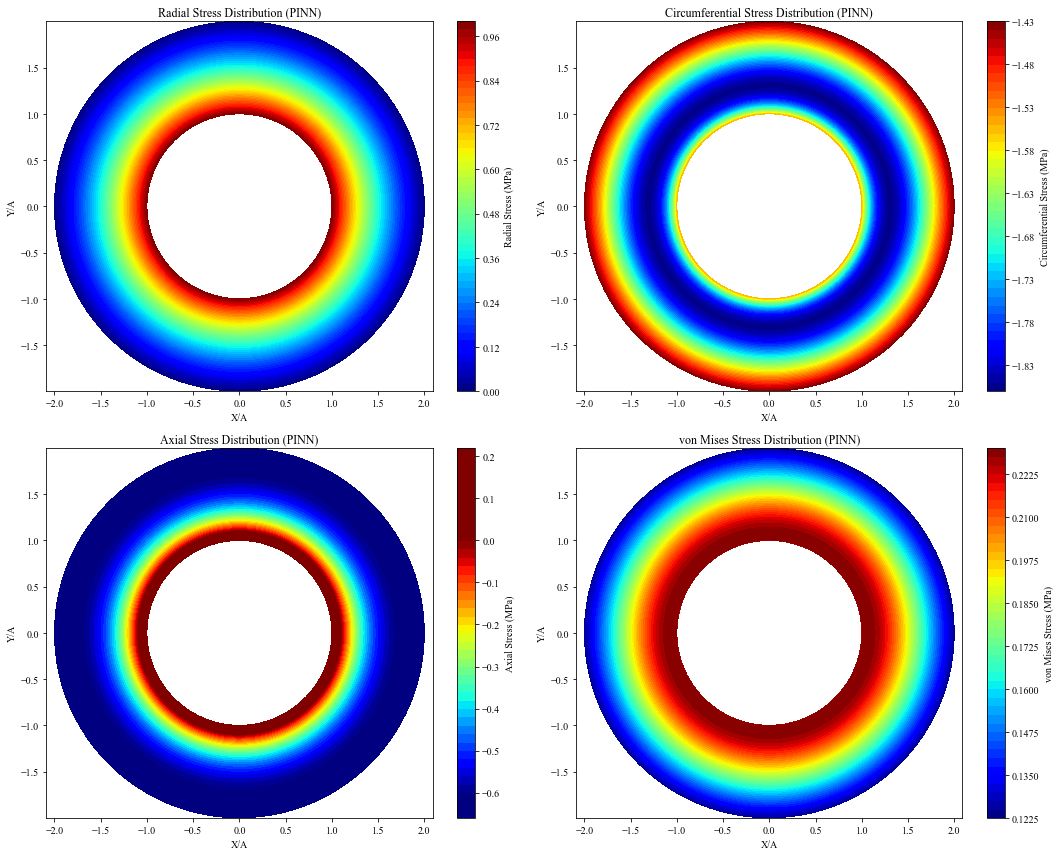

In [23]:
# 创建图形
plt.figure(figsize=(15, 12))

# 径向应力分布
plt.subplot(2, 2, 1)
contour1 = plt.contourf(X_PINN/A, Y_PINN/A, sigma_r_2d, 50, cmap='jet',vmin=0, vmax=1)
plt.colorbar(contour1,label='Radial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Radial Stress Distribution (PINN)')
plt.axis('equal')

# 环向应力分布
plt.subplot(2, 2, 2)
contour2 = plt.contourf(X_PINN/A, Y_PINN/A, sigma_theta_2d, 50, cmap='jet')
plt.colorbar(contour2, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Circumferential Stress Distribution (PINN)')
plt.axis('equal')

# 轴向应力分布
plt.subplot(2, 2, 3)
contour3 = plt.contourf(X_PINN/A, Y_PINN/A, sigma_z_2d, 50, cmap='jet',vmin=-0.6, vmax=0)

plt.colorbar(contour3, label='Axial Stress (MPa)')

plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Axial Stress Distribution (PINN)')
plt.axis('equal')

# 变形比分布
plt.subplot(2, 2, 4)
contour4 = plt.contourf(X_PINN/A, Y_PINN/A, von_mises_2d, 50, cmap='jet')
plt.colorbar(contour4, label='von Mises Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('von Mises Stress Distribution (PINN)')
plt.axis('equal')

plt.tight_layout()
plt.savefig(r'E:\李辉\超弹性球柱PINN求解\COMSOL分析\new\FG圆柱\双参数幂函数形式\Neohookean\优化结果\PINN_2D_distribution.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()



In [24]:
# 创建极坐标网格
theta = np.linspace(0, 2 * np.pi, 100)
R_1 = COMSOL_R.flatten()  # 展平半径数组
Theta, R_grid1 = np.meshgrid(theta, R_1)
X_COMSOL = R_grid1 * np.cos(Theta)
Y_COMSOL = R_grid1 * np.sin(Theta)

# 将一维FDM数据扩展为二维网格数据
COMSOL_sigma_r_2d = np.tile(COMSOL_sigma_r.flatten(), (len(theta), 1)).T
COMSOL_sigma_theta_2d = np.tile(COMSOL_sigma_theta.flatten(), (len(theta), 1)).T
COMSOL_sigma_z_2d = np.tile(COMSOL_sigma_z.flatten() , (len(theta), 1)).T
COMSOL_lamdatheta_2d = np.tile(COMSOL_lamdatheta.flatten(), (len(theta), 1)).T
COMSOL_von_mises_2d = np.tile(COMSOL_von_mises.flatten(), (len(theta), 1)).T
COMSOL_miu_2d = np.tile(COMSOL_miu.flatten(), (len(theta), 1)).T

In [25]:
data_dict = {
    'R_1': R_grid1.flatten(),  # 半径网格
    'Theta': Theta.flatten(),  # 角度网格
    'X': X_COMSOL.flatten(),  # X坐标
    'Y': Y_COMSOL.flatten(),  # Y坐标
    'COMSOL_sigma_r_2d': COMSOL_sigma_r_2d.flatten(),  # σ_r 数据
    'COMSOL_sigma_theta_2d': COMSOL_sigma_theta_2d.flatten(),  # σ_θ 数据
    'COMSOL_sigma_z_2d': COMSOL_sigma_z_2d.flatten(),  # σ_z 数据
    'COMSOL_lamdatheta_2d': COMSOL_lamdatheta_2d.flatten(),  # λθ 数据
    'COMSOL_von_mises_2d': COMSOL_von_mises_2d.flatten(),  # λθ 数据
    'COMSOL_miu_2d': COMSOL_miu_2d.flatten()  # λθ 数据
}

# 将字典转换为 DataFrame
df = pd.DataFrame(data_dict)

# 保存为 CSV 文件
output_path = r'E:\李辉\超弹性球柱PINN求解\COMSOL分析\new\FG圆柱\双参数幂函数形式\Neohookean\优化结果\COMSOL_2D_data.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

print(f'极坐标数据已保存到 {output_path}')

极坐标数据已保存到 E:\李辉\超弹性球柱PINN求解\COMSOL分析\new\FG圆柱\双参数幂函数形式\Neohookean\优化结果\COMSOL_2D_data.csv


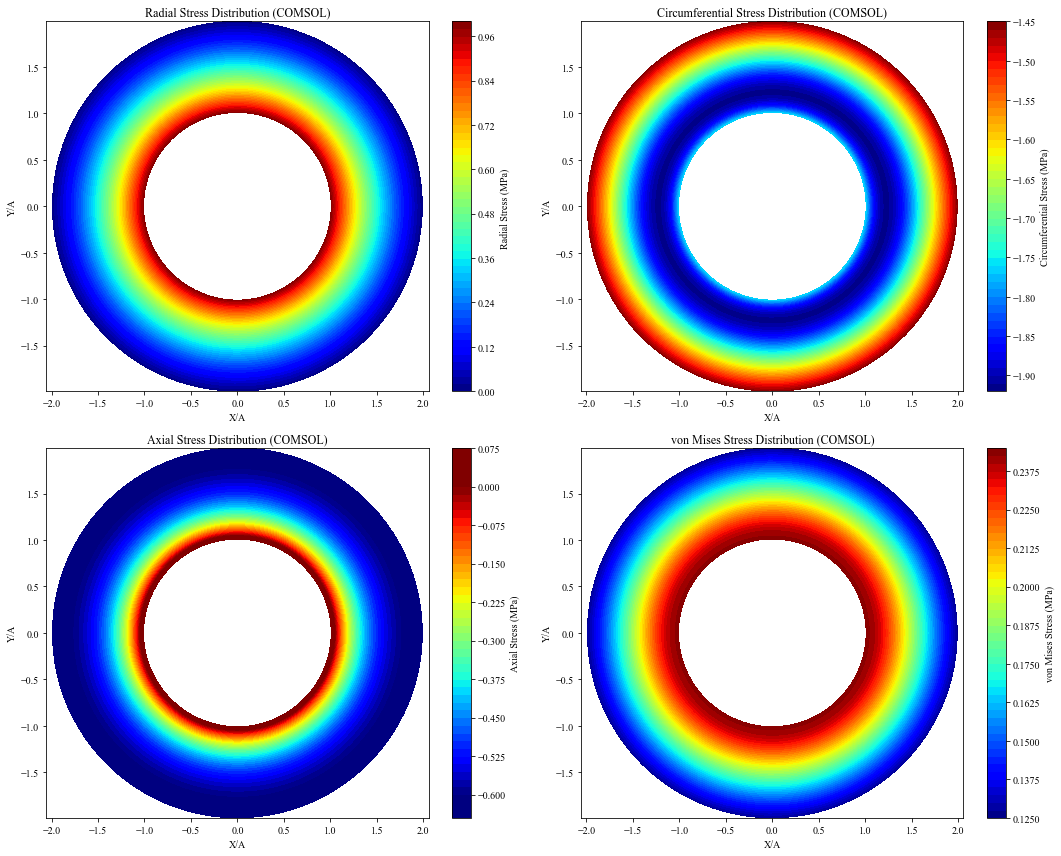

In [26]:

# 创建图形
plt.figure(figsize=(15, 12))
# 径向应力分布
plt.subplot(2, 2, 1)
contour1 = plt.contourf(X_COMSOL/A, Y_COMSOL/A, COMSOL_sigma_r_2d, 50, cmap='jet')
plt.colorbar(contour1, label='Radial Stress (MPa) ')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Radial Stress Distribution (COMSOL)')
plt.axis('equal')

# 环向应力分布
plt.subplot(2, 2, 2)
contour2 = plt.contourf(X_COMSOL/A, Y_COMSOL/A, COMSOL_sigma_theta_2d, 50, cmap='jet')
plt.colorbar(contour2, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Circumferential Stress Distribution (COMSOL)')
plt.axis('equal')

# 轴向应力分布
plt.subplot(2, 2, 3)
contour3 = plt.contourf(X_COMSOL/A, Y_COMSOL/A, COMSOL_sigma_z_2d, 50, cmap='jet',vmin=-0.6, vmax=0)
plt.colorbar(contour3, label='Axial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Axial Stress Distribution (COMSOL)')
plt.axis('equal')

# 变形比分布
plt.subplot(2, 2, 4)
contour4 = plt.contourf(X_COMSOL/A, Y_COMSOL/A, COMSOL_von_mises_2d, 50, cmap='jet')
plt.colorbar(contour4, label='von Mises Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('von Mises Stress Distribution (COMSOL)')
plt.axis('equal')

plt.tight_layout()
plt.savefig(r'E:\李辉\超弹性球柱PINN求解\COMSOL分析\new\FG圆柱\双参数幂函数形式\Neohookean\优化结果\COMSOL_2D_distribution.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()

In [27]:
import numpy as np
from scipy.interpolate import interp1d


def PINN_to_COMSOL(R_pinn, value_pinn, R_comsol, kind='cubic'):


    # ---------- 转成一维 ----------
    R_pinn = np.asarray(R_pinn).flatten()
    value_pinn = np.asarray(value_pinn).flatten()
    R_comsol = np.asarray(R_comsol).flatten()

    # ---------- 按坐标排序 ----------
    index = np.argsort(R_pinn)

    R_pinn = R_pinn[index]
    value_pinn = value_pinn[index]

    # ---------- 去掉可能重复的坐标 ----------
    R_pinn, unique_index = np.unique(R_pinn, return_index=True)
    value_pinn = value_pinn[unique_index]

    # ---------- 构造插值函数 ----------
    f_interp = interp1d(
        R_pinn,
        value_pinn,
        kind=kind,
        bounds_error=False,
        fill_value="extrapolate"
    )

    # ---------- 在 COMSOL 坐标处计算 ----------
    value_interp = f_interp(R_comsol)

    return value_interp

In [28]:

sigma_r_PINN_COMSOL = PINN_to_COMSOL(R_phys/A, sigma_r_phys/1e6, R_bar_COMSOL)

sigma_theta_PINN_COMSOL = PINN_to_COMSOL(R_phys/A, sigma_theta_phys/1e6, R_bar_COMSOL)

sigma_z_PINN_COMSOL = PINN_to_COMSOL(R_phys/A, sigma_z_phys/1e6, R_bar_COMSOL)

von_mises_PINN_COMSOL = PINN_to_COMSOL(R_phys/A, von_mises, R_bar_COMSOL)

miu_PINN_COMSOL = PINN_to_COMSOL(R_phys/A, miu_phys/1e6, R_bar_COMSOL)

lamdatheta_PINN_COMSOL = PINN_to_COMSOL( R_phys/A, lamdatheta_phys, R_bar_COMSOL)

In [29]:
COMSOL_sigma_r = COMSOL_sigma_r_2d[:, 0]
COMSOL_sigma_theta = COMSOL_sigma_theta_2d[:, 0]
COMSOL_sigma_z = COMSOL_sigma_z_2d[:, 0]
COMSOL_von_mises = COMSOL_von_mises_2d[:, 0]
COMSOL_miu = COMSOL_miu_2d[:, 0]
COMSOL_lamdatheta = COMSOL_lamdatheta_2d[:, 0]

In [30]:
print(COMSOL_R.shape)
print(sigma_r_PINN_COMSOL.shape)
print(COMSOL_sigma_r.shape)

(50,)
(50,)
(50,)


In [31]:
# 计算L2相对误差
def L2_relative_error(true_values, computed_values):
    numerator = np.sqrt(np.sum((true_values - computed_values) ** 2))  # 分子：计算误差的L2范数
    denominator = np.sqrt(np.sum(true_values ** 2))  # 分母：实际值的L2范数
    return numerator / denominator

In [32]:
sigma_r__L2_error =L2_relative_error(sigma_r_PINN_COMSOL, COMSOL_sigma_r)
sigma_theta__L2_error =L2_relative_error(sigma_theta_PINN_COMSOL, COMSOL_sigma_theta)
sigma_z__L2_error =L2_relative_error(sigma_z_PINN_COMSOL, COMSOL_sigma_z)
von_mises__L2_error =L2_relative_error(von_mises_PINN_COMSOL, COMSOL_von_mises)
miu__L2_error =L2_relative_error(miu_PINN_COMSOL, COMSOL_miu)
lamdatheta__L2_error =L2_relative_error(lamdatheta_PINN_COMSOL, COMSOL_lamdatheta)

In [33]:
import numpy as np
from scipy.interpolate import interp1d


def PINN_2D_to_COMSOL(R_pinn, value_pinn_2d, R_comsol, kind='linear'):


    # 1. 坐标转为一维

    R_pinn = np.asarray(R_pinn).flatten()
    R_comsol = np.asarray(R_comsol).flatten()


    # 2. 二维场

    value_pinn_2d = np.asarray(value_pinn_2d)


    # 3. 检查径向维度

    if value_pinn_2d.shape[0] != len(R_pinn):

        # 如果数据实际上是 (Ntheta, Nr)
        if value_pinn_2d.shape[1] == len(R_pinn):
            value_pinn_2d = value_pinn_2d.T

        else:
            raise ValueError(
                f"PINN径向坐标长度为 {len(R_pinn)}, "
                f"但二维数据尺寸为 {value_pinn_2d.shape}"
            )

    # 4. 按 R 排序

    index = np.argsort(R_pinn)

    R_pinn = R_pinn[index]
    value_pinn_2d = value_pinn_2d[index, :]


    # 5. 删除重复 R

    R_pinn, unique_index = np.unique(R_pinn,return_index=True)

    value_pinn_2d = value_pinn_2d[unique_index, :]


    # 6. 沿第0维，径向插值

    f = interp1d(
        R_pinn,
        value_pinn_2d,
        axis=0,
        kind=kind,
        bounds_error=False,
        fill_value="extrapolate"
    )

    value_interp_2d = f(R_comsol)

    return value_interp_2d

In [34]:
sigma_r_PINN_COMSOL_2d = PINN_2D_to_COMSOL(R_phys/A,sigma_r_2d,R_bar_COMSOL)

sigma_theta_PINN_COMSOL_2d = PINN_2D_to_COMSOL(R_phys/A,sigma_theta_2d,R_bar_COMSOL)

sigma_z_PINN_COMSOL_2d = PINN_2D_to_COMSOL(R_phys/A,sigma_z_2d,R_bar_COMSOL)

lamdatheta_PINN_COMSOL_2d = PINN_2D_to_COMSOL(R_phys/A,lamdatheta_2d,R_bar_COMSOL)

von_mises_PINN_COMSOL_2d = PINN_2D_to_COMSOL(R_phys/A, von_mises_2d, R_bar_COMSOL)


In [36]:
sigma_r_2d_error= abs(sigma_r_PINN_COMSOL_2d-COMSOL_sigma_r_2d)
sigma_theta_2d_error= abs(sigma_theta_PINN_COMSOL_2d-COMSOL_sigma_theta_2d)
sigma_z_2d_error=abs(sigma_z_PINN_COMSOL_2d-COMSOL_sigma_z_2d)
lamdatheta_2d_error=abs(lamdatheta_PINN_COMSOL_2d-COMSOL_lamdatheta_2d)
von_mises_2d_error=abs(von_mises_PINN_COMSOL_2d-COMSOL_von_mises_2d)

# 打印误差结果
print(f"Sigma_r 2D abs Error: {np.max(sigma_r_2d_error)}")
print(f"sigma_theta 2D abs Error: {np.max(sigma_theta_2d_error)}")
print(f"Sigma_z 2D abs Error: {np.max(sigma_z_2d_error)}")
print(f"von_mises 2D abs Error: {np.max(von_mises_2d_error)}")
print(f"lamdatheta_2d abs Error: {np.max(lamdatheta_2d_error)}")

Sigma_r 2D abs Error: 0.0013259222921960245
sigma_theta 2D abs Error: 0.18702660183387665
Sigma_z 2D abs Error: 0.12447848331856057
von_mises 2D abs Error: 0.015253224169361868
lamdatheta_2d abs Error: 0.012111851581348088


In [37]:
# 计算各个误差
sigma_r_2d_L2_error = L2_relative_error(sigma_r_PINN_COMSOL_2d, COMSOL_sigma_r_2d)
sigma_theta_2d_L2_error = L2_relative_error(sigma_theta_PINN_COMSOL_2d, COMSOL_sigma_theta_2d)
sigma_z_2d_L2_error = L2_relative_error(sigma_z_PINN_COMSOL_2d, COMSOL_sigma_z_2d)
lamdatheta_2d_L2_error = L2_relative_error(lamdatheta_PINN_COMSOL_2d, COMSOL_lamdatheta_2d)
von_mises_2d_L2_error = L2_relative_error(von_mises_PINN_COMSOL_2d, COMSOL_von_mises_2d)

# 打印误差结果
print(f"Sigma_r 2D L2 Relative Error: {sigma_r_2d_L2_error}")
print(f"sigma_theta 2D L2 Relative Error: {sigma_theta_2d_L2_error}")
print(f"Sigma_z 2D L2 Relative Error: {sigma_z_2d_L2_error}")
print(f"von_mises 2D L2 Relative Error: {von_mises_2d_L2_error}")
print(f"lamdatheta_2d L2 Relative Error: {lamdatheta_2d_L2_error}")

Sigma_r 2D L2 Relative Error: 0.0016442249708798675
sigma_theta 2D L2 Relative Error: 0.04002644759910054
Sigma_z 2D L2 Relative Error: 0.09440226534427379
von_mises 2D L2 Relative Error: 0.029900423356116944
lamdatheta_2d L2 Relative Error: 0.004391681395505854


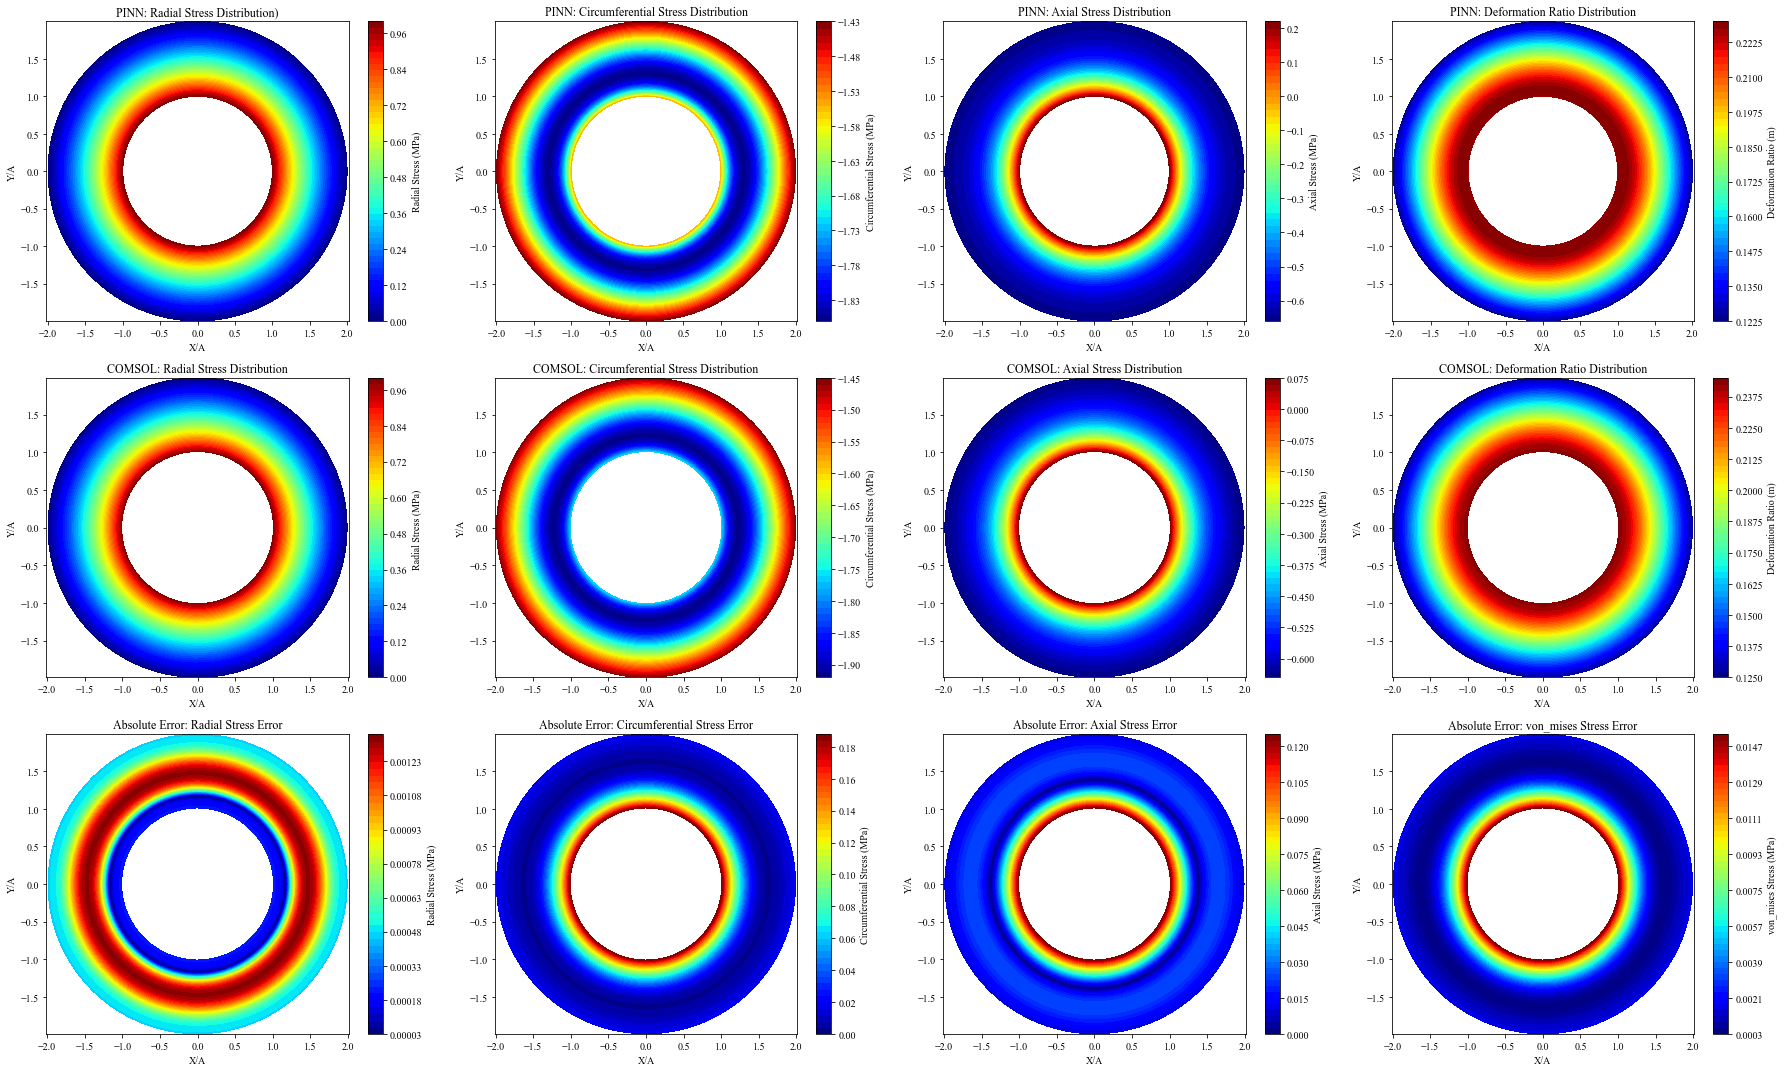

In [39]:
# 创建图形3x3排列
plt.figure(figsize=(25, 15))

# 第一排：PINN结果

# 第一列：PINN径向应力
plt.subplot(3, 4, 1)

contour1 = plt.contourf(X_PINN/A, Y_PINN/A, sigma_r_2d, 50, cmap='jet')
plt.colorbar(contour1,label='Radial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Radial Stress Distribution)')
plt.axis('equal')

# 第二列：PINN环向应力
plt.subplot(3, 4, 2)

contour2 = plt.contourf(X_PINN/A, Y_PINN/A, sigma_theta_2d, 50, cmap='jet')
plt.colorbar(contour2, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Circumferential Stress Distribution')
plt.axis('equal')

# 第三列：PINN轴向应力
plt.subplot(3, 4, 3)

contour3 = plt.contourf(X_PINN/A, Y_PINN/A, sigma_z_2d, 50, cmap='jet')

plt.colorbar(contour3, label='Axial Stress (MPa)')

plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Axial Stress Distribution')
plt.axis('equal')


# 第四列：PINN伸长比
plt.subplot(3, 4, 4)
contour4 = plt.contourf(X_PINN/A, Y_PINN/A, von_mises_2d, 50, cmap='jet')
plt.colorbar(contour4, label='Deformation Ratio (m)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Deformation Ratio Distribution')
plt.axis('equal')


# 第二排：FDM结果

# 第一列：FDM径向应力
plt.subplot(3, 4, 5)
contour5 = plt.contourf(X_COMSOL/A, Y_COMSOL/A, COMSOL_sigma_r_2d, 50, cmap='jet')
plt.colorbar(contour5, label='Radial Stress (MPa) ')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Radial Stress Distribution')
plt.axis('equal')


# 第二列：COMSOL环向应力
plt.subplot(3, 4, 6)
contour6 = plt.contourf(X_COMSOL/A, Y_COMSOL/A, COMSOL_sigma_theta_2d, 50, cmap='jet')
plt.colorbar(contour6, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Circumferential Stress Distribution')
plt.axis('equal')


# 第三列：COMSOL轴向应力
plt.subplot(3, 4, 7)
contour7 = plt.contourf(X_COMSOL/A, Y_COMSOL/A, COMSOL_sigma_z_2d, 50, cmap='jet')
plt.colorbar(contour7, label='Axial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Axial Stress Distribution')
plt.axis('equal')


# 第四列：COMSOL伸长比
plt.subplot(3, 4, 8)
contour8 = plt.contourf(X_COMSOL/A, Y_COMSOL/A, COMSOL_von_mises_2d, 50, cmap='jet')
plt.colorbar(contour8, label='Deformation Ratio (m)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Deformation Ratio Distribution')
plt.axis('equal')



# 第三排：误差

# 第一列：位移误差
plt.subplot(3, 4, 9)
contour9 = plt.contourf(X_COMSOL/A, Y_COMSOL/A, sigma_r_2d_error, 50, cmap='jet')
plt.colorbar(contour9, label='Radial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Absolute Error: Radial Stress Error')
plt.axis('equal')

# 第二列：径向应力误差
plt.subplot(3, 4, 10)
contour10 = plt.contourf(X_COMSOL/A, Y_COMSOL/A,sigma_theta_2d_error, 50, cmap='jet')
plt.colorbar(contour10, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Absolute Error: Circumferential Stress Error')
plt.axis('equal')



# 第三列：环向应力误差
plt.subplot(3, 4, 11)
contour11 = plt.contourf(X_COMSOL/A, Y_COMSOL/A,sigma_z_2d_error, 50, cmap='jet')
plt.colorbar(contour11, label='Axial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Absolute Error: Axial Stress Error')
plt.axis('equal')



# 第四列：环向应力误差
plt.subplot(3, 4, 12)
# contour12 = plt.contourf(X_COMSOL/A, Y_COMSOL/A, lamdatheta_2d_error, 50, cmap='jet')
# plt.colorbar(contour12, label='Deformation Ratio (m)')
# plt.xlabel('X/A')
# plt.ylabel('Y/A')
# plt.title('Absolute Error: Deformation Ratio Error')
# plt.axis('equal')

contour12 = plt.contourf(X_COMSOL/A, Y_COMSOL/A, von_mises_2d_error, 50, cmap='jet')
plt.colorbar(contour12, label='von_mises Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Absolute Error: von_mises Stress Error')
plt.axis('equal')

# 调整布局以避免标签重叠
plt.tight_layout()

plt.savefig(r'E:\李辉\超弹性球柱PINN求解\COMSOL分析\new\FG圆柱\双参数幂函数形式\Neohookean\优化结果\sanzu_2D_distribution.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()


In [40]:
output_dir = r'E:\李辉\超弹性球柱PINN求解\COMSOL分析\new\FG圆柱\双参数幂函数形式\Neohookean\优化结果'

os.makedirs(output_dir, exist_ok=True)

# 1. 保存 PINN


PINN_data_dict = {
    'X_A': (X_PINN/A).flatten(),
    'Y_A': (Y_PINN/A).flatten(),
    'sigma_r': sigma_r_2d.flatten(),
    'sigma_theta': sigma_theta_2d.flatten(),
    'sigma_z': sigma_z_2d.flatten(),
     'von_mises': von_mises_2d.flatten(),
    'lamdatheta': lamdatheta_2d.flatten()
}

df_PINN = pd.DataFrame(PINN_data_dict)

PINN_output_path = os.path.join( output_dir,'PINN_2D_data.csv')

df_PINN.to_csv(PINN_output_path,index=False,encoding='utf-8')

print(f'PINN二维数据已保存到：{PINN_output_path}')


# 2. 保存 COMSOL 

COMSOL_data_dict = {
    'X_A': (X_COMSOL/A).flatten(),
    'Y_A': (Y_COMSOL/A).flatten(),
    'sigma_r': COMSOL_sigma_r_2d.flatten(),
    'sigma_theta': COMSOL_sigma_theta_2d.flatten(),
    'sigma_z': COMSOL_sigma_z_2d.flatten(),
    'von_mises':COMSOL_von_mises_2d.flatten(),
    'lamdatheta': COMSOL_lamdatheta_2d.flatten()
}

df_COMSOL = pd.DataFrame(COMSOL_data_dict)

COMSOL_output_path = os.path.join(output_dir,'COMSOL_2D_data.csv')

df_COMSOL.to_csv(COMSOL_output_path,index=False,encoding='utf-8')

print(f'COMSOL二维数据已保存到：{COMSOL_output_path}')


# 3. 保存绝对误差


Error_data_dict = {
    'X_A': (X_COMSOL/A).flatten(),
    'Y_A': (Y_COMSOL/A).flatten(),
    'sigma_r_error': sigma_r_2d_error.flatten(),
    'sigma_theta_error': sigma_theta_2d_error.flatten(),
    'sigma_z_error': sigma_z_2d_error.flatten(),
    'von_mises_error': von_mises_2d_error.flatten()
}

df_Error = pd.DataFrame(Error_data_dict)

Error_output_path = os.path.join(output_dir,'Error_2D_data.csv')

df_Error.to_csv(Error_output_path,index=False,encoding='utf-8')

print(f'二维绝对误差数据已保存到：{Error_output_path}')

PINN二维数据已保存到：E:\李辉\超弹性球柱PINN求解\COMSOL分析\new\FG圆柱\双参数幂函数形式\Neohookean\优化结果\PINN_2D_data.csv
COMSOL二维数据已保存到：E:\李辉\超弹性球柱PINN求解\COMSOL分析\new\FG圆柱\双参数幂函数形式\Neohookean\优化结果\COMSOL_2D_data.csv
二维绝对误差数据已保存到：E:\李辉\超弹性球柱PINN求解\COMSOL分析\new\FG圆柱\双参数幂函数形式\Neohookean\优化结果\Error_2D_data.csv
